In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import copy
from pathlib import Path
from PIL import Image

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from torchinfo import summary

from tqdm.auto import tqdm

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Using device: {device}")

Using device: cuda


In [5]:
!pip install grad-cam

In [6]:
class Config:
    DATA_DIR = "/kaggle/input/datasets/youcefattallah97/minerals-identification-classification/Minet 5640 Images"
    IMG_SIZE = 224
    BATCH_SIZE = 32
    LR = 1e-5
    EPOCHS = 20
    RANDOM_STATE = 42
    MODEL_SAVE_PATH = "best_model.pth"

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        Config.IMG_SIZE,
        scale=(0.8, 1.0),
        ratio=(0.9, 1.1)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
base_dataset = ImageFolder(Config.DATA_DIR)
targets = base_dataset.targets
NUM_CLASSES = len(base_dataset.classes)

In [8]:
indices = np.arange(len(targets))

# Train (70%) and temp (30%)
train_idx, temp_idx, y_train, y_temp = train_test_split(
    indices,
    targets,
    test_size=0.3,
    stratify=targets,
    random_state=Config.RANDOM_STATE
)

# Split temp into val (15%) and test (15%)
val_idx, test_idx, _, _ = train_test_split(
    temp_idx,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=Config.RANDOM_STATE
)

In [9]:
# full datasets with different transforms
train_dataset_full = ImageFolder(Config.DATA_DIR, transform=train_transform)
val_dataset_full = ImageFolder(Config.DATA_DIR, transform=val_test_transform)
test_dataset_full = ImageFolder(Config.DATA_DIR, transform=val_test_transform)

# apply indices
train_dataset = Subset(train_dataset_full, train_idx)
val_dataset = Subset(val_dataset_full, val_idx)
test_dataset = Subset(test_dataset_full, test_idx)

print(f"Train: {len(train_dataset)}")
print(f"Val: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")

Train: 3948
Val: 846
Test: 846


In [10]:
train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False)

In [11]:
weights = EfficientNet_B3_Weights.IMAGENET1K_V1
model = efficientnet_b3(weights=weights)

num_ftrs = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, NUM_CLASSES)
)

for param in model.features[-3:].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 172MB/s]


In [12]:
summary(model, input_size=(1, 3, Config.IMG_SIZE, Config.IMG_SIZE))

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [1, 7]                    --
├─Sequential: 1-1                                       [1, 1536, 7, 7]           --
│    └─Conv2dNormActivation: 2-1                        [1, 40, 112, 112]         --
│    │    └─Conv2d: 3-1                                 [1, 40, 112, 112]         1,080
│    │    └─BatchNorm2d: 3-2                            [1, 40, 112, 112]         80
│    │    └─SiLU: 3-3                                   [1, 40, 112, 112]         --
│    └─Sequential: 2-2                                  [1, 24, 112, 112]         --
│    │    └─MBConv: 3-4                                 [1, 24, 112, 112]         2,298
│    │    └─MBConv: 3-5                                 [1, 24, 112, 112]         1,206
│    └─Sequential: 2-3                                  [1, 32, 56, 56]           --
│    │    └─MBConv: 3-6                            

In [13]:
train_labels = [label for _, label in train_dataset]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights:", class_weights)

Class weights: tensor([0.7530, 1.9249, 1.4960, 0.8069, 2.3402, 0.7421, 0.6803],
       device='cuda:0')


In [14]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW([
    {"params": model.features.parameters(), "lr": Config.LR},
    {"params": model.classifier.parameters(), "lr": Config.LR * 10} # Classifier usually benefits from a higher LR
])

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=2,
    threshold=1e-3
)

In [16]:
def train_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs=15, model_save_path="best_model.pth"):
    train_loader, val_loader = dataloaders

    history = {
        "accuracy": [],
        "val_accuracy": [],
        "loss": [],
        "val_loss": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")

    for epoch in range(num_epochs):
        print(f"\nEpoch [{epoch+1}/{num_epochs}]")
        print("-" * 50)

        # =========================
        # TRAINING
        # =========================
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_samples = 0

        train_bar = tqdm(train_loader, desc="Training", leave=False)

        for inputs, labels in train_bar:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            preds = outputs.argmax(dim=1)

            loss.backward()
            optimizer.step()

            batch_size = inputs.size(0)
            running_loss += loss.item() * batch_size
            running_corrects += (preds == labels).sum().item()
            total_samples += batch_size

            train_bar.set_postfix(
                loss=f"{loss.item():.4f}",
                acc=f"{running_corrects / total_samples:.4f}"
            )

        epoch_train_loss = running_loss / total_samples
        epoch_train_acc = running_corrects / total_samples

        # =========================
        # VALIDATION
        # =========================
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        val_samples = 0

        val_bar = tqdm(val_loader, desc="Validation", leave=False)

        with torch.no_grad():
            for inputs, labels in val_bar:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                preds = outputs.argmax(dim=1)

                batch_size = inputs.size(0)
                val_loss += loss.item() * batch_size
                val_corrects += (preds == labels).sum().item()
                val_samples += batch_size

                val_bar.set_postfix(
                    loss=f"{loss.item():.4f}",
                    acc=f"{val_corrects / val_samples:.4f}"
                )

        epoch_val_loss = val_loss / val_samples
        epoch_val_acc = val_corrects / val_samples

        scheduler.step(epoch_val_loss)

        history["accuracy"].append(epoch_train_acc)
        history["val_accuracy"].append(epoch_val_acc)
        history["loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)

        print(
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Train Acc: {epoch_train_acc:.4f}"
        )
        print(
            f"Val Loss:   {epoch_val_loss:.4f} | "
            f"Val Acc:   {epoch_val_acc:.4f}"
        )

        # Save best model
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), model_save_path)
            print(f"Saved best model with validation loss {best_val_loss:.4f} to {model_save_path}")

    model.load_state_dict(best_model_wts)
    return model, history

In [17]:
model, history = train_model(
    model,
    [train_loader, val_loader],
    criterion,
    optimizer,
    scheduler,
    num_epochs=Config.EPOCHS,
    model_save_path=Config.MODEL_SAVE_PATH
)


Epoch [1/20]
--------------------------------------------------


Training:   0%|          | 0/124 [00:00<?, ?it/s]

Validation:   0%|          | 0/27 [00:00<?, ?it/s]

Train Loss: 1.5775 | Train Acc: 0.4324
Val Loss:   1.2570 | Val Acc:   0.5969
Saved best model with validation loss 1.2570 to best_model.pth

Epoch [2/20]
--------------------------------------------------


Training:   0%|          | 0/124 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/27 [00:00<?, ?it/s]

Train Loss: 0.2979 | Train Acc: 0.9053
Val Loss:   0.4190 | Val Acc:   0.9007
Saved best model with validation loss 0.4190 to best_model.pth

Epoch [20/20]
--------------------------------------------------


Training:   0%|          | 0/124 [00:00<?, ?it/s]

Validation:   0%|          | 0/27 [00:00<?, ?it/s]

Train Loss: 0.2802 | Train Acc: 0.9113
Val Loss:   0.4101 | Val Acc:   0.9102
Saved best model with validation loss 0.4101 to best_model.pth


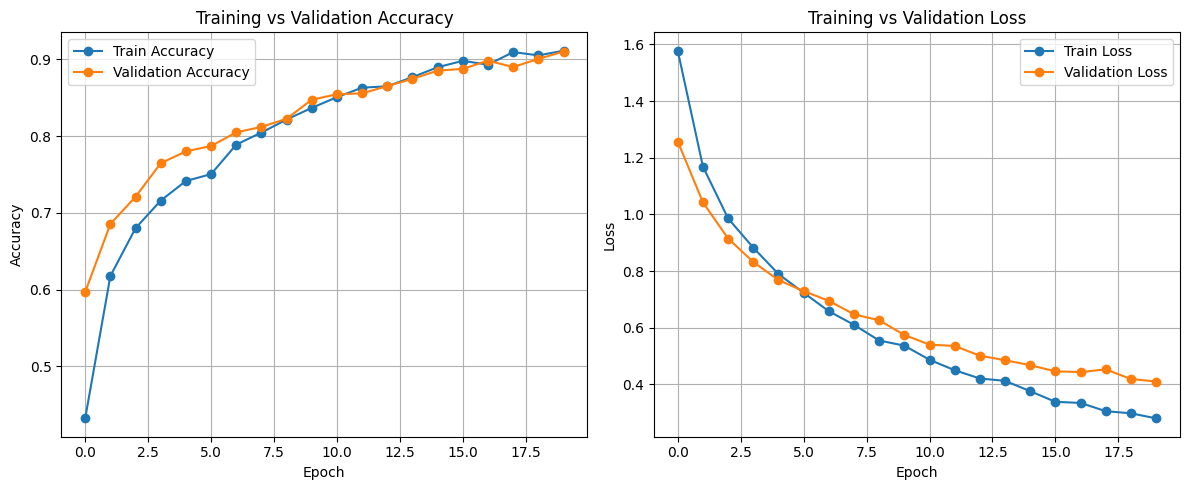

In [18]:
plt.figure(figsize=(12, 5))

# Accuracy curve
plt.subplot(1, 2, 1)
plt.plot(history["accuracy"], marker="o", label="Train Accuracy")
plt.plot(history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(history["loss"], marker="o", label="Train Loss")
plt.plot(history["val_loss"], marker="o", label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [19]:
model.eval()

running_corrects = 0
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        preds = outputs.argmax(dim=1)

        running_corrects += (preds == labels).sum().item()

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

test_acc = running_corrects / len(test_dataset)

print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9125


In [20]:
print(classification_report(y_true, y_pred, target_names=base_dataset.classes))

              precision    recall  f1-score   support

     biotite       0.94      0.94      0.94       160
     bornite       0.86      0.79      0.83        63
 chrysocolla       0.87      0.81      0.84        81
   malachite       0.90      0.95      0.92       149
   muscovite       0.84      0.81      0.82        52
      pyrite       0.92      0.96      0.94       163
      quartz       0.94      0.93      0.94       178

    accuracy                           0.91       846
   macro avg       0.90      0.89      0.89       846
weighted avg       0.91      0.91      0.91       846



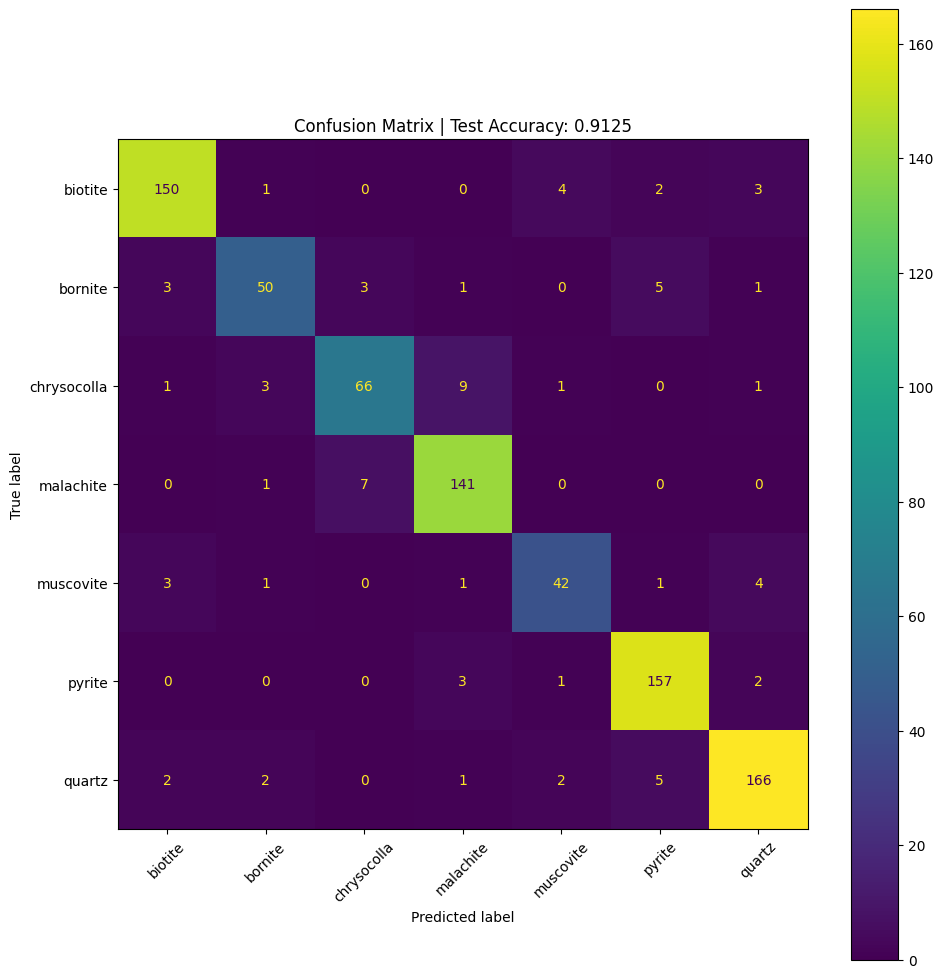

In [21]:
fig, ax = plt.subplots(figsize=(10, 10))

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=base_dataset.classes,
    xticks_rotation=45,
    ax=ax
)

ax.set_title(f"Confusion Matrix | Test Accuracy: {test_acc:.4f}")
plt.tight_layout()
plt.show()

In [23]:
target_layers = [model.features[-1]] 
cam = GradCAM(model=model, target_layers=target_layers)

In [26]:
def unnormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (img_tensor * std + mean).permute(1, 2, 0).cpu().numpy()

def visualize_gradcam(model, image_tensor, label, class_names, cam_model):

    model.eval()

    image = image_tensor.unsqueeze(0).to(device)

    targets = [ClassifierOutputTarget(label)]

    grayscale_cam = cam_model(
        input_tensor=image,
        targets=targets
    )[0]

    rgb_image = unnormalize(image_tensor)

    visualization = show_cam_on_image(
        rgb_image,
        grayscale_cam,
        use_rgb=True,
        image_weight = 0.6
    )

    with torch.no_grad():
        output = model(image)
        probs = torch.softmax(output, dim=1)

    confidence, pred = torch.max(probs, 1)

    pred_class = class_names[pred.item()]
    true_class = class_names[label]

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(rgb_image)
    plt.title(f"True: {true_class}")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(visualization)
    plt.title(
        f"Pred: {pred_class}\n"
        f"Confidence: {confidence.item()*100:.2f}%"
    )
    plt.axis("off")

    plt.show()

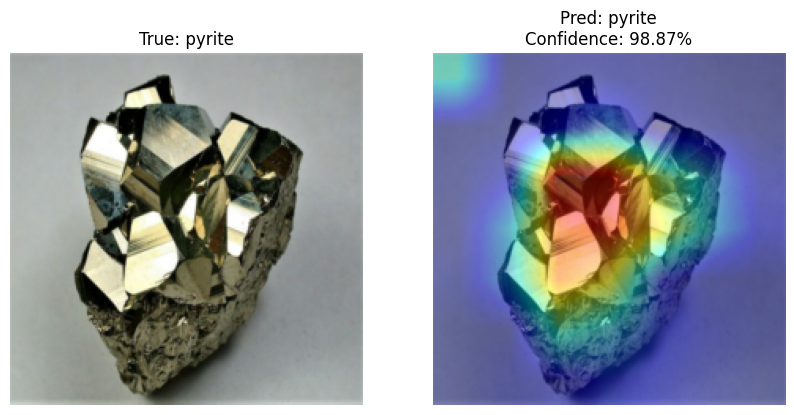

In [27]:
images, labels = next(iter(test_loader))
class_names = base_dataset.classes

visualize_gradcam(
    model,
    images[3],
    labels[3].item(),
    class_names,
    cam
)

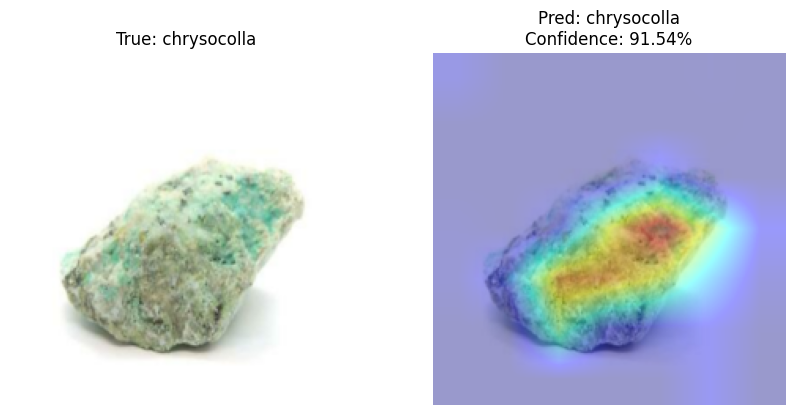

In [29]:
visualize_gradcam(
    model,
    images[4],
    labels[4].item(),
    class_names,
    cam
)